In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [51]:
# Loading all 5 Instacart CSV files into df
aisles_df=pd.read_csv("aisles.csv")
departments_df=pd.read_csv("departments.csv")
orderproducts_df=pd.read_csv("order_products__prior.csv")
orders_df=pd.read_csv("orders.csv")
products_df=pd.read_csv("products.csv")

In [52]:
aisles_df.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [53]:
aisles_df.dtypes

aisle_id     int64
aisle       object
dtype: object

In [54]:
aisles_df.isnull().sum()

aisle_id    0
aisle       0
dtype: int64

In [55]:
aisles_df.size

268

In [56]:
departments_df.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [57]:
departments_df.dtypes

department_id     int64
department       object
dtype: object

In [58]:
departments_df.isnull().sum()

department_id    0
department       0
dtype: int64

In [59]:
departments_df.size

42

In [60]:
orderproducts_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [61]:
orderproducts_df.isnull().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

In [62]:
orderproducts_df.size

129737956

In [63]:
orderproducts_df.dtypes

order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object

In [64]:
orders_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [65]:
orders_df.dtypes

order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

In [66]:
orders_df.isnull().sum()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

In [67]:
orders_df.size

23947581

In [68]:
products_df.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [69]:
products_df.dtypes

product_id        int64
product_name     object
aisle_id          int64
department_id     int64
dtype: object

In [70]:
products_df.isnull().sum()

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

In [72]:
products_df.size

198752

In [74]:
import sqlite3

In [73]:
conn=sqlite3.connect("instacart.db")

In [26]:
# Write each DataFrame to its own SQLite table
for df,tbl in [(aisles_df,"aisles"),(departments_df,"departments"),(orderproducts_df,"orderproducts"),(orders_df,"orders"),(products_df,"products")]:
    df.to_sql(tbl,conn,if_exists="replace",index=False)

In [77]:
# Commit all table
conn.commit()

In [76]:
# Confirming all 5 tables were created in SQLite
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,aisles
1,departments
2,orderproducts
3,orders
4,products


In [78]:
# Full RFM analysis: raw metrics, NTILE scoring, segment labels
rfm_df=pd.read_sql("""WITH rfm AS (
              SELECT user_id,
              COUNT(DISTINCT orders.order_id) AS frequency,
              MIN(days_since_prior_order) AS recency,
              COUNT(orderproducts.product_id) AS monetary
              FROM orders
              JOIN orderproducts ON orders.order_id = orderproducts.order_id
              WHERE eval_set = 'prior'
              GROUP BY user_id),
            scored AS (
              SELECT *,
             NTILE(4) OVER (ORDER BY recency DESC) AS r_score,
             NTILE(4) OVER (ORDER BY frequency) AS f_score,
             NTILE(4) OVER (ORDER BY monetary) AS m_score
              FROM rfm)
            SELECT *,
              CAST(r_score AS TEXT) || CAST(f_score AS TEXT) || CAST(m_score AS TEXT) AS rfm_cell,
              CASE 
                WHEN r_score >= 3 AND f_score >= 3 AND m_score >= 3 THEN 'Best Customers'
                WHEN r_score >= 3 AND f_score >= 2 THEN 'Loyal Customers'
                WHEN r_score >= 3 AND f_score < 2 THEN 'New Customers'
                WHEN r_score < 3 AND f_score >= 3 THEN 'At Risk'
                ELSE 'Lost Customers'
                  END AS segment
                FROM scored""", conn)

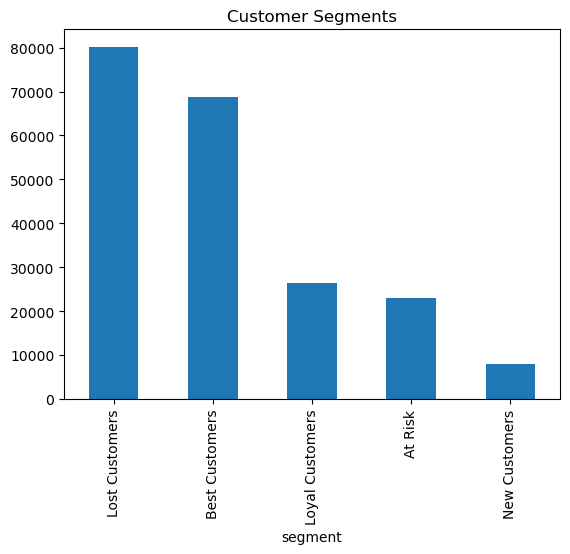

In [79]:
# Visualize customer segment distribution (bar chart)
rfm_df['segment'].value_counts().plot(kind='bar', title='Customer Segments')
plt.show()

In [80]:
# RF heatmap: recency score vs frequency score cross-tabulation
pd.crosstab(rfm_df['r_score'], rfm_df['f_score']).style.background_gradient()

f_score,1,2,3,4
r_score,,,,
1,31230,16619,3622,82
2,12446,19823,15597,3686
3,6080,11648,19035,14789
4,1797,3462,13298,32995


In [82]:
# Validate NTILE quartiles (25% each) and segment proportions
print(rfm_df[['r_score', 'f_score', 'm_score']].describe())
print(rfm_df['segment'].value_counts(normalize=True))

             r_score        f_score        m_score
count  206209.000000  206209.000000  206209.000000
mean        2.499993       2.499993       2.499993
std         1.118039       1.118039       1.118039
min         1.000000       1.000000       1.000000
25%         1.000000       1.000000       1.000000
50%         2.000000       2.000000       2.000000
75%         3.000000       3.000000       3.000000
max         4.000000       4.000000       4.000000
segment
Lost Customers     0.388528
Best Customers     0.333531
Loyal Customers    0.128268
At Risk            0.111474
New Customers      0.038199
Name: proportion, dtype: float64


## Conclusions & Insights

The RFM analysis segmented **206,209 customers** into 5 behavioral groups based on their ordering patterns:

| Segment | % of Users | Profile | Recommendation |
|---|---|---|---|
| **Lost Customers** | 38.9% | Low recency & low frequency | Re-engagement campaigns, discount offers |
| **Best Customers** | 33.4% | High on all 3 metrics (R/F/M) | Loyalty perks, early access, VIP treatment |
| **Loyal Customers** | 12.8% | Good recency & frequency | Nurture with personalized recommendations |
| **At Risk** | 11.1% | Were frequent but recently inactive | Win-back emails, targeted promotions |
| **New Customers** | 3.8% | Recent first order only | Onboarding flow, encourage repeat purchase |

**Key findings:**
- The RF heatmap shows users cluster on the diagonal (R = F), meaning ordering recency and frequency are strongly correlated
- **72% of users** are polarized into either "Best Customers" or "Lost Customers" — a clear retention opportunity lies in the middle segments
- The ~39% lost segment represents significant potential revenue recovery through targeted re-engagement strategies
- New customers (3.8%) are a small but important group — improving their conversion to repeat buyers could shift the segment distribution favorably